# Proton Energy Spectrum

Converts TOF (from `time_of_flight.ipynb`'s onset-to-onset numbers) into proton energy,
using the x-ray onset as t=0 at the source. Physics and constants recovered from the
original `preliminary.ipynb`/`shot16.ipynb` (which did this exact conversion before this
project's notebooks existed):

```
TOF_proton = (t_proton_onset - t_xray_onset) + L / c
```

The `+ L/c` matters: the x-ray onset marks when the x-ray *arrives at the detector*, not
when it left the source -- since it took `L/c` to get there, that light-travel time has to
be added back to reference t=0 at the source itself.

`v = L / TOF`, `beta = v/c`, `gamma = 1/sqrt(1-beta^2)`, and kinetic energy uses the
relativistic form `(gamma-1) * m_p * c^2` once beta > 0.1 (classical `0.5*m_p*v^2`
otherwise) -- same cutoff the original notebooks used.

**Flight distance `L` is not constant across the campaign** -- Gage says it changed
*after* shot 11. `L = 3.12` m is confirmed for shots 15+ (matches `shot16.ipynb` /
`spectrum.ipynb`, which both used it). The pre-shot-11 distance (for shots 9 and 11) is
**not yet known** -- `SHOT_DISTANCE_M` below has `None` for those two as a placeholder;
fill it in once you have it. Until then those two shots are skipped, not guessed at.

**Validation note**: reproducing the original notebook's exact baseline-crossing algorithm
against the *current* shot16.h5 data gives dt=29.19ns, not the 38.47ns saved in
shot16.ipynb's output -- the file itself has likely changed since that original analysis
(shot16.h5 is flagged in shot_log.py as "not in SLUG.tar, found loose in the parent dir,
copied in", so it isn\'t guaranteed to be byte-identical to what was originally analyzed).
Reassuringly, the original algorithm and this notebook\'s onset-based pipeline *agree* with
each other on the current data (29.19 vs 28.91ns) -- so what follows is internally
consistent, just potentially different from that one old saved run.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shot_log as sl
from helpers import load_channel
from shot_characterization.characterize import characterize
from shot_characterization import VERIFIED_CATEGORY, find_xray_shape, find_proton_onset

# physical constants
c = 299_792_458.0        # m/s
m_p = 1.67262192369e-27  # kg, proton mass
q_e = 1.602176634e-19    # C

# source-to-detector distance -- NOT constant across the campaign (changed
# after shot 11). None = not yet known; those shots are skipped below.
SHOT_DISTANCE_M = {
    9: None,     # pre-shot-11 distance, unknown -- fill in when available
    11: None,    # pre-shot-11 distance, unknown -- fill in when available
    15: 3.12,
    16: 3.12,
    18: 3.12,
    19: 3.12,
    20: 3.12,
    21: 3.12,
    22: 3.12,
    27: 3.12,
}

BROKEN_PROTON_SHOTS = {25, 26}  # see proton_analysis.ipynb


## Check on one shot

In [2]:
def tof_to_energy(tof_s, L):
    v_proton = L / tof_s
    beta = v_proton / c
    gamma = 1 / (1 - beta**2) ** 0.5
    ke_classical_kev = (0.5 * m_p * v_proton**2) / q_e / 1e3
    ke_rel_kev = ((gamma - 1) * m_p * c**2) / q_e / 1e3
    ke_kev = ke_rel_kev if beta > 0.1 else ke_classical_kev
    return dict(v_proton=v_proton, beta=beta, gamma=gamma,
                ke_classical_kev=ke_classical_kev, ke_rel_kev=ke_rel_kev,
                ke_kev=ke_kev, relativistic=beta > 0.1)


def shot_energy(shot, verbose=True):
    L = SHOT_DISTANCE_M.get(shot)
    if L is None:
        if verbose:
            print(f"shot {shot}: distance L unknown, skipping")
        return None

    entry = sl.main_channel_entry(shot)
    kind, path, ch = entry
    t, v, clipped, ydisp = load_channel(sl.DATA_DIR, kind, path, ch)
    res = characterize(t, v, clipped)
    baseline, noise = res["baseline_V"], res["noise_V"]

    xr = find_xray_shape(t, v, baseline, noise)
    pr = find_proton_onset(t, v, baseline, xr["peak_i"])
    if xr is None or pr is None:
        if verbose:
            print(f"shot {shot}: x-ray or proton onset not found")
        return None

    dt_ns = pr["onset_time_ns"] - xr["onset_time_ns"]
    L_over_c_ns = (L / c) * 1e9
    tof_ns = dt_ns + L_over_c_ns
    e = tof_to_energy(tof_ns * 1e-9, L)

    if verbose:
        tag = "relativistic" if e["relativistic"] else "classical"
        print(f"shot {shot}: dt={dt_ns:.3f}ns  L/c={L_over_c_ns:.3f}ns  TOF={tof_ns:.3f}ns  "
              f"beta={e['beta']:.4f}  KE={e['ke_kev']/1e3:.3f} MeV ({tag})")

    return dict(shot=shot, L=L, dt_ns=dt_ns, tof_ns=tof_ns, **e)


shot_energy(16)


shot 16: dt=28.914ns  L/c=10.407ns  TOF=39.321ns  beta=0.2647  KE=34.697 MeV (relativistic)


{'shot': 16,
 'L': 3.12,
 'dt_ns': 28.914062499999986,
 'tof_ns': 39.32126227018233,
 'v_proton': 79346384.6242272,
 'beta': 0.26467104994424906,
 'gamma': 1.036979997243683,
 'ke_classical_kev': 32863.338626110446,
 'ke_rel_kev': 34697.299233999685,
 'ke_kev': 34697.299233999685,
 'relativistic': True}

## Every shot with a known distance

In [3]:
DOUBLE_PULSE_SHOTS = sorted(s for s, cat in VERIFIED_CATEGORY.items()
                            if cat == "Double pulse (prompt + delayed candidate)")
ENERGY_SHOTS = [s for s in DOUBLE_PULSE_SHOTS if s not in BROKEN_PROTON_SHOTS]
print(f"{len(DOUBLE_PULSE_SHOTS)} double-pulse shots, {len(ENERGY_SHOTS)} usable for TOF, "
      f"{sum(1 for s in ENERGY_SHOTS if SHOT_DISTANCE_M.get(s) is not None)} with a known distance")

for shot in ENERGY_SHOTS:
    shot_energy(shot)


12 double-pulse shots, 10 usable for TOF, 8 with a known distance
shot 9: distance L unknown, skipping
shot 11: distance L unknown, skipping
shot 15: dt=35.711ns  L/c=10.407ns  TOF=46.118ns  beta=0.2257  KE=24.843 MeV (relativistic)
shot 16: dt=28.914ns  L/c=10.407ns  TOF=39.321ns  beta=0.2647  KE=34.697 MeV (relativistic)
shot 18: dt=31.641ns  L/c=10.407ns  TOF=42.048ns  beta=0.2475  KE=30.131 MeV (relativistic)
shot 19: dt=38.695ns  L/c=10.407ns  TOF=49.103ns  beta=0.2119  KE=21.812 MeV (relativistic)
shot 20: dt=26.805ns  L/c=10.407ns  TOF=37.212ns  beta=0.2797  KE=38.998 MeV (relativistic)
shot 21: dt=32.758ns  L/c=10.407ns  TOF=43.165ns  beta=0.2411  KE=28.521 MeV (relativistic)
shot 22: dt=27.734ns  L/c=10.407ns  TOF=38.142ns  beta=0.2729  KE=37.007 MeV (relativistic)
shot 27: dt=34.273ns  L/c=10.407ns  TOF=44.681ns  beta=0.2329  KE=26.537 MeV (relativistic)


## Summary table

In [4]:
rows = []
for shot in ENERGY_SHOTS:
    r = shot_energy(shot, verbose=False)
    info = sl.SHOT_LOG[shot]
    if r is None:
        rows.append(dict(shot=shot, target=info["target"], thickness_um=info["thickness_um"],
                          L_m=SHOT_DISTANCE_M.get(shot), tof_ns=None, beta=None, ke_mev=None))
        continue
    rows.append(dict(
        shot=shot, target=info["target"], thickness_um=info["thickness_um"],
        L_m=r["L"], tof_ns=round(r["tof_ns"], 3), beta=round(r["beta"], 4),
        ke_mev=round(r["ke_kev"] / 1e3, 3),
    ))

energy_df = pd.DataFrame(rows).set_index("shot")
energy_df


,target,thickness_um,L_m,tof_ns,beta,ke_mev
shot,,,,,,
9,Cu,25.0,NaN,NaN,NaN,NaN
11,Al,25.0,NaN,NaN,NaN,NaN
15,Cu film,100.0,3.12,46.118,0.2257,24.843
16,Mylar,1.0,3.12,39.321,0.2647,34.697
18,Al,12.5,3.12,42.048,0.2475,30.131
19,rod,NaN,3.12,49.103,0.2119,21.812
20,Mylar,1.0,3.12,37.212,0.2797,38.998
21,Mylar,1.0,3.12,43.165,0.2411,28.521
22,Mylar,1.0,3.12,38.142,0.2729,37.007


## Energy spectrum (amplitude vs. energy across the whole proton pulse)

Every sample between the proton pulse's onset and end gets its own TOF (and therefore its
own energy) -- earlier-arriving samples are higher-energy protons, later ones are lower
energy. Same idea as `preliminary.ipynb`/`shot16.ipynb`'s original spectrum plot: convert
each sample's arrival time to energy, then plot amplitude (~ proton flux) against that
energy axis instead of time.

Check on one shot first.


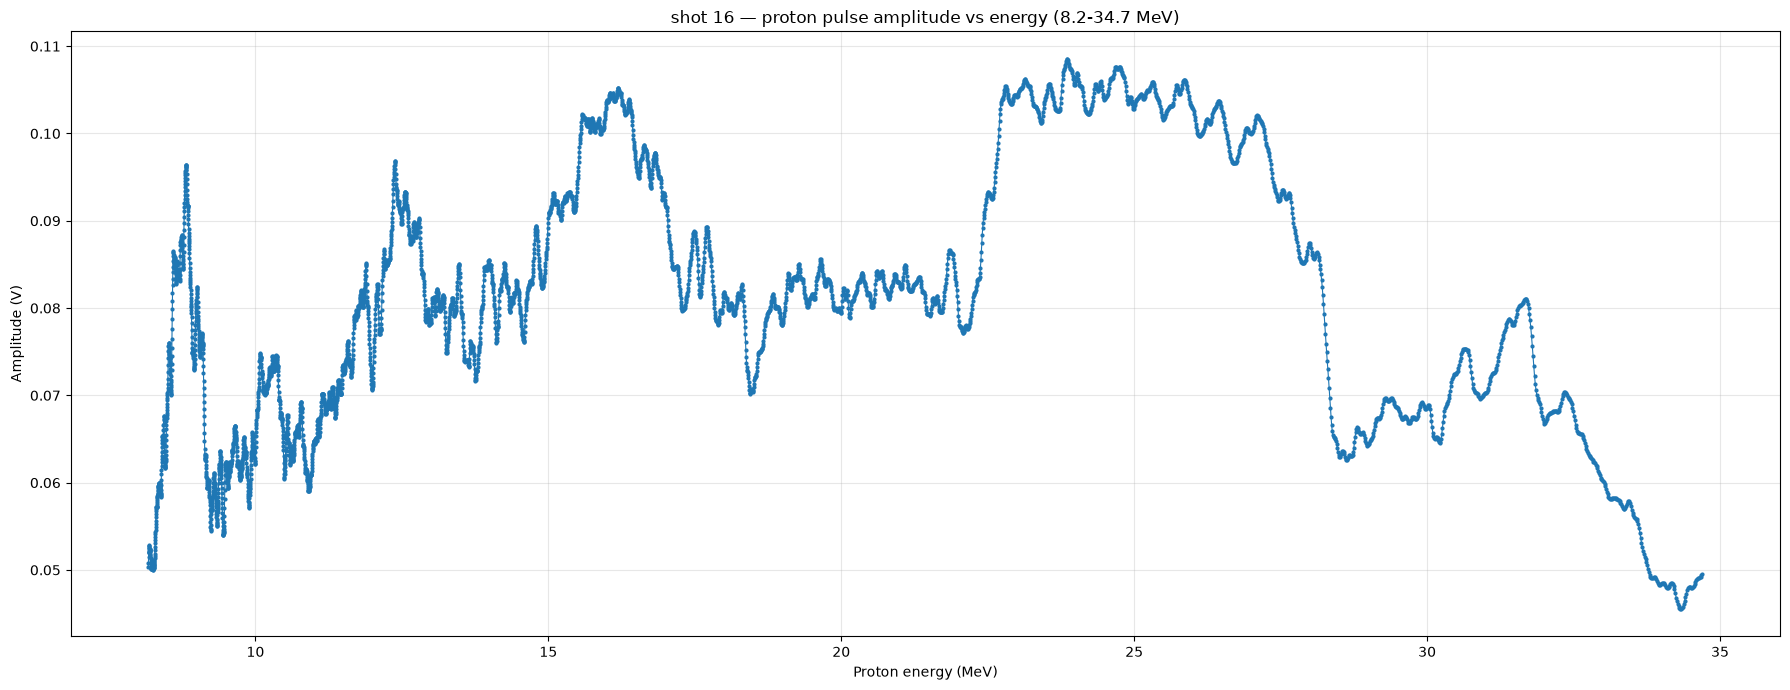

(array([34.69729923, 34.68274209, 34.66819427, ...,  8.17508941,
         8.17345883,  8.17182874], shape=(5127,)),
 array([0.0495235 , 0.04938406, 0.04924462, ..., 0.05143091, 0.05084159,
        0.05033908], shape=(5127,)))

In [5]:
def energy_spectrum_for_shot(shot):
    L = SHOT_DISTANCE_M.get(shot)
    if L is None:
        print(f"shot {shot}: distance L unknown, skipping")
        return None

    entry = sl.main_channel_entry(shot)
    kind, path, ch = entry
    t, v, clipped, ydisp = load_channel(sl.DATA_DIR, kind, path, ch)
    res = characterize(t, v, clipped)
    baseline, noise = res["baseline_V"], res["noise_V"]

    xr = find_xray_shape(t, v, baseline, noise)
    pr = find_proton_onset(t, v, baseline, xr["peak_i"])
    if xr is None or pr is None:
        print(f"shot {shot}: x-ray or proton onset not found")
        return None

    t_ns = t * 1e9
    mask = (t_ns >= pr["onset_time_ns"]) & (t_ns <= pr["end_time_ns"])
    t_pulse = t_ns[mask]
    v_pulse = v[mask]

    L_over_c_ns = (L / c) * 1e9
    tof_pulse_s = (t_pulse - xr["onset_time_ns"] + L_over_c_ns) * 1e-9
    v_pulse_proton = L / tof_pulse_s
    beta_pulse = v_pulse_proton / c
    gamma_pulse = 1 / np.sqrt(1 - beta_pulse**2)
    energy_pulse_mev = (gamma_pulse - 1) * m_p * c**2 / q_e / 1e6

    # TOF decreases as energy increases, so later (in time) samples come
    # first in raw order -- sort so the plotted energy axis is ascending
    order = np.argsort(energy_pulse_mev)

    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(energy_pulse_mev[order], v_pulse[order], marker="o", markersize=2, linewidth=0.8)
    ax.set_xlabel("Proton energy (MeV)")
    ax.set_ylabel("Amplitude (V)")
    ax.set_title(f"shot {shot} — proton pulse amplitude vs energy "
                 f"({energy_pulse_mev.min():.1f}-{energy_pulse_mev.max():.1f} MeV)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return energy_pulse_mev, v_pulse


energy_spectrum_for_shot(16)


## Energy spectrum for every shot with a known distance


shot 9: distance L unknown, skipping
shot 11: distance L unknown, skipping


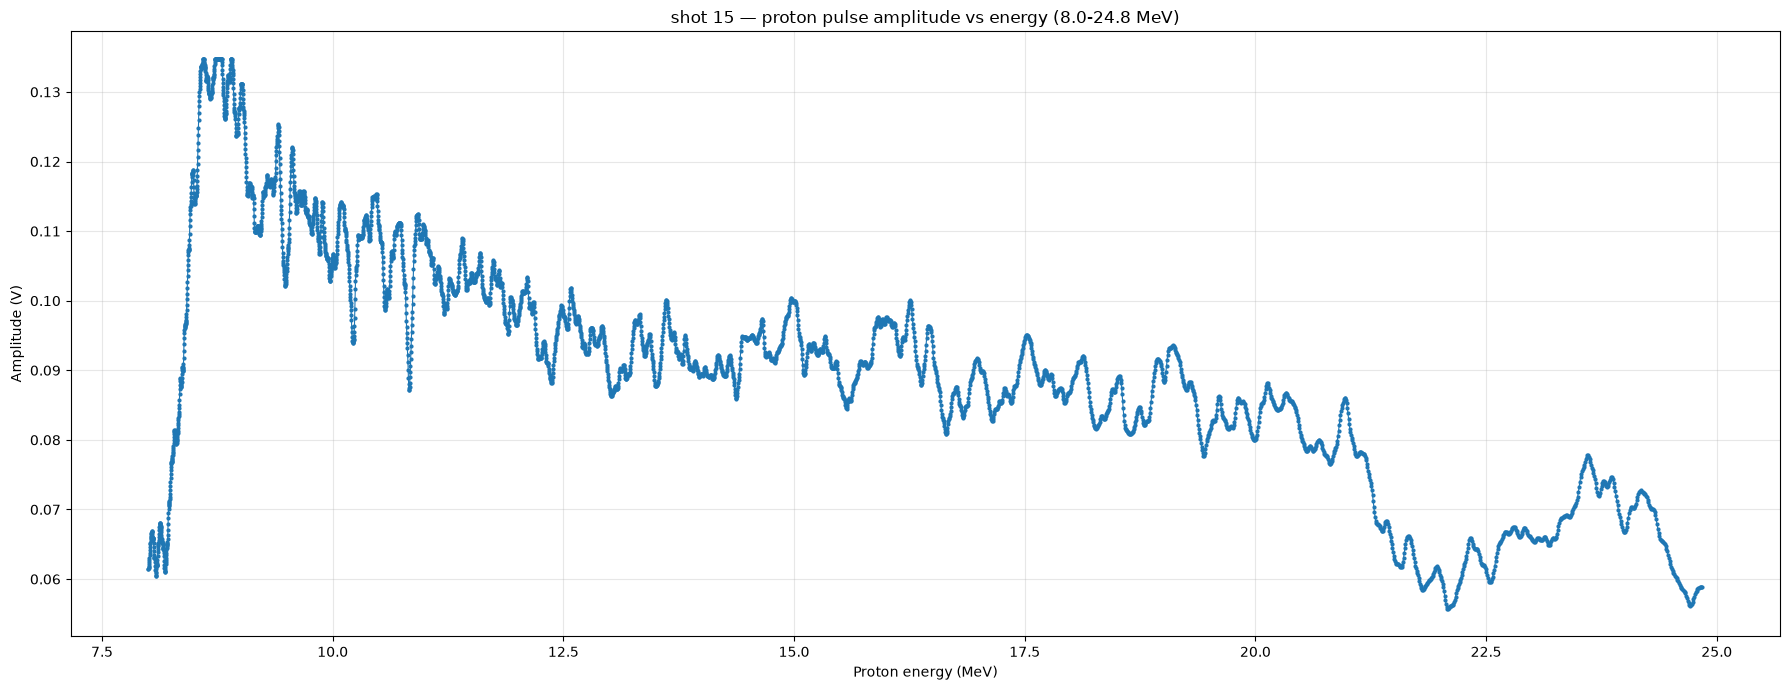

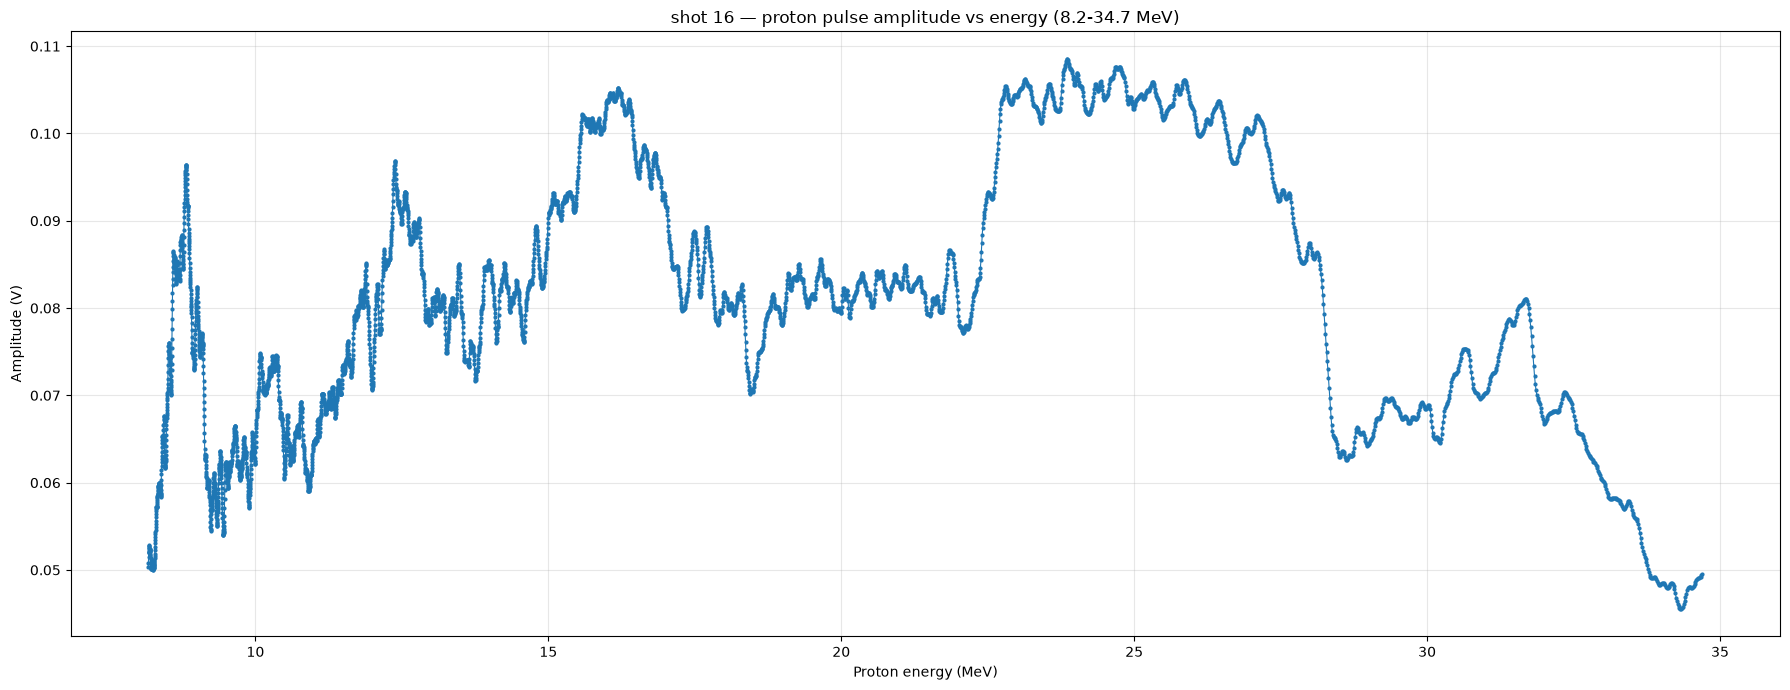

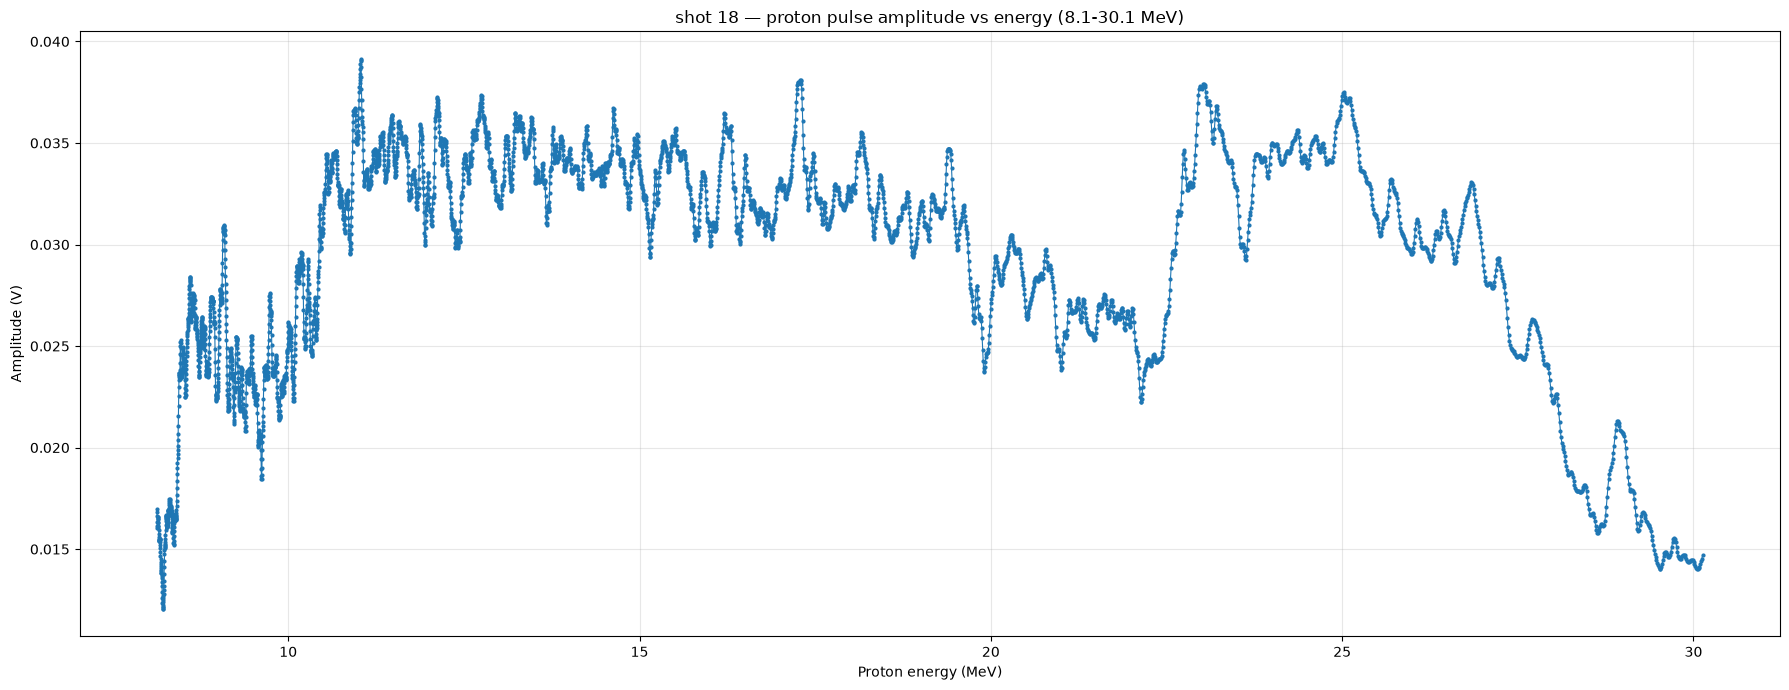

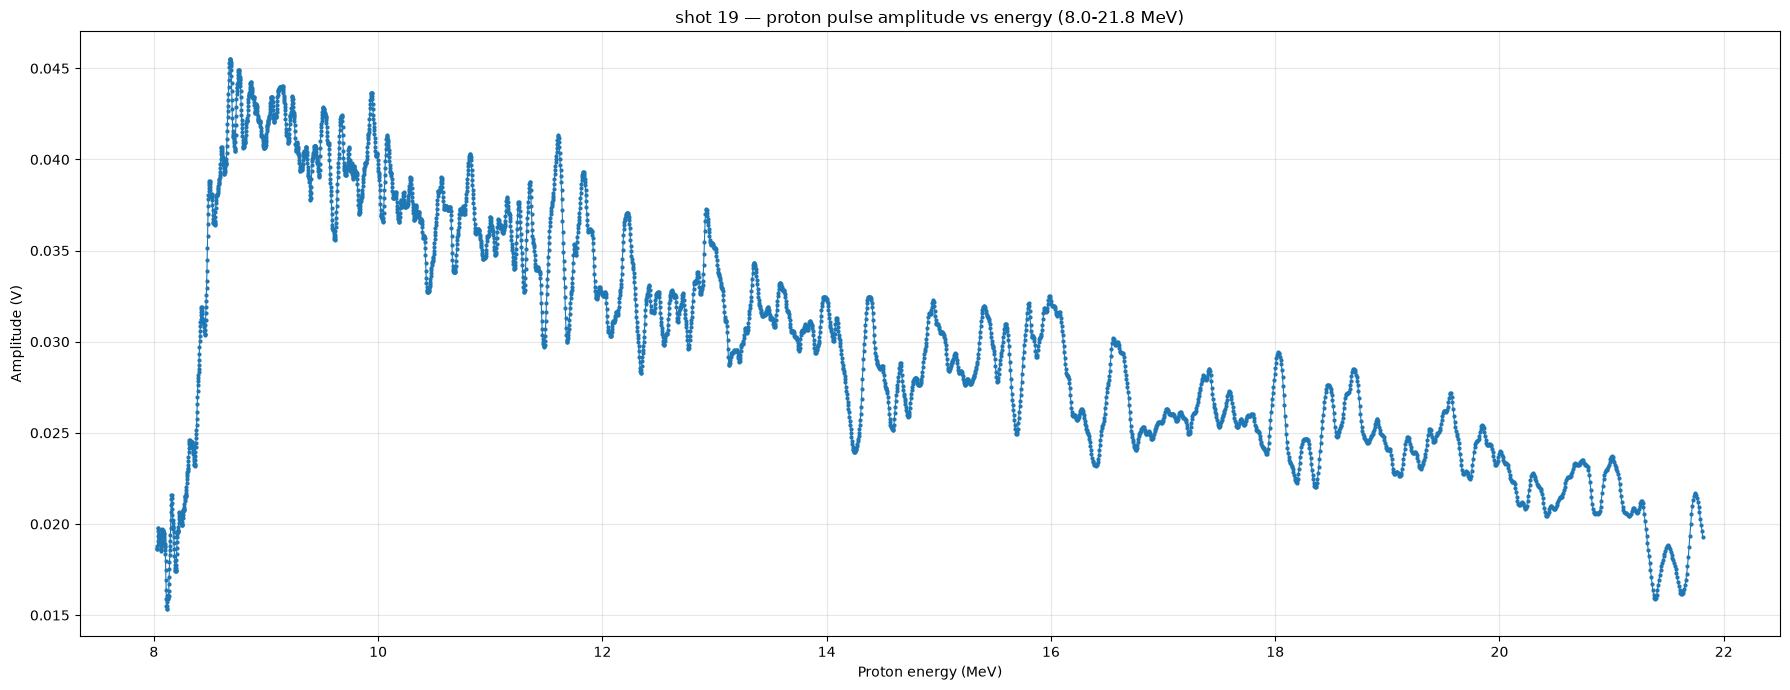

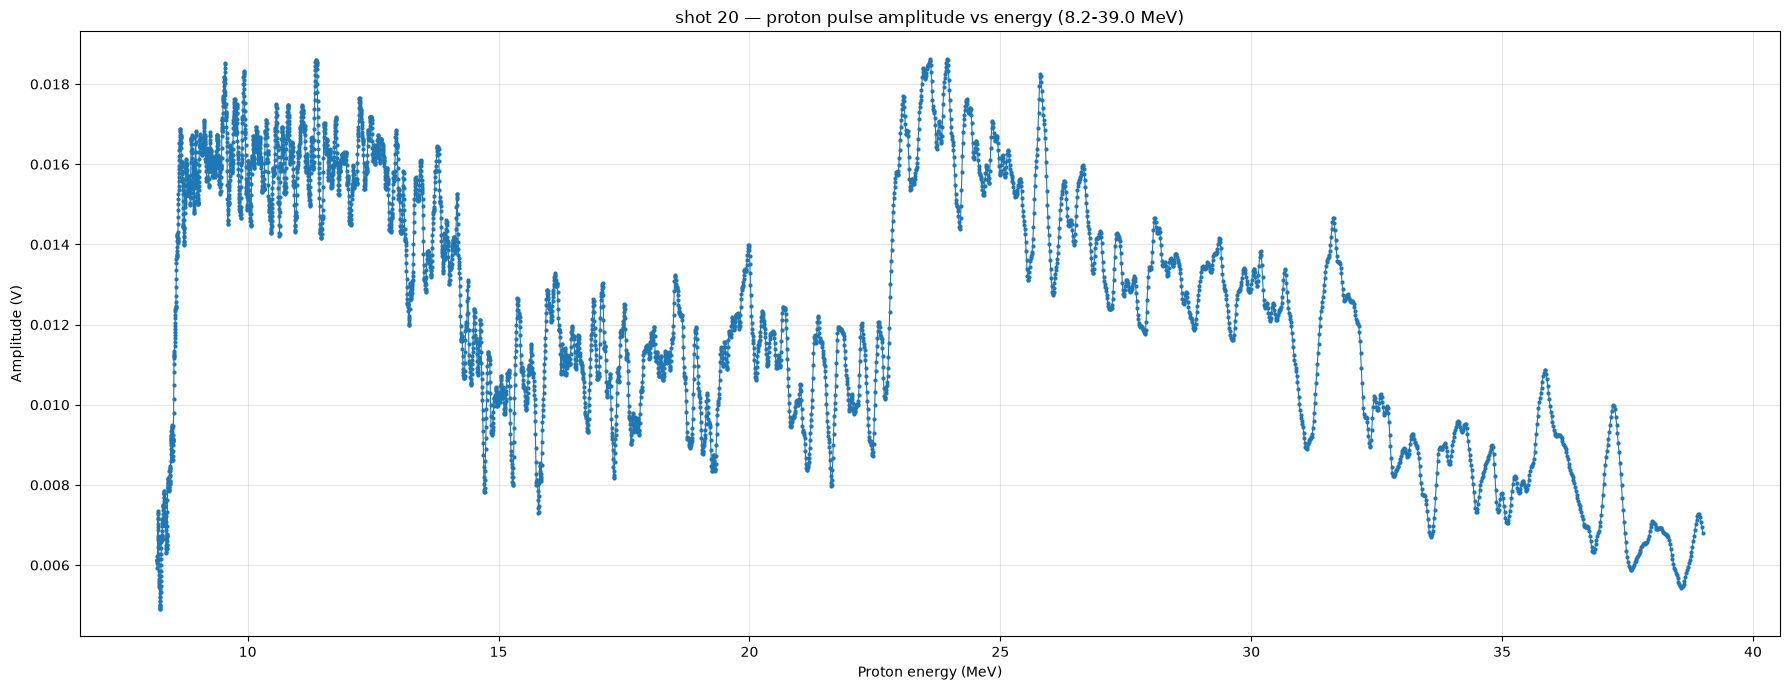

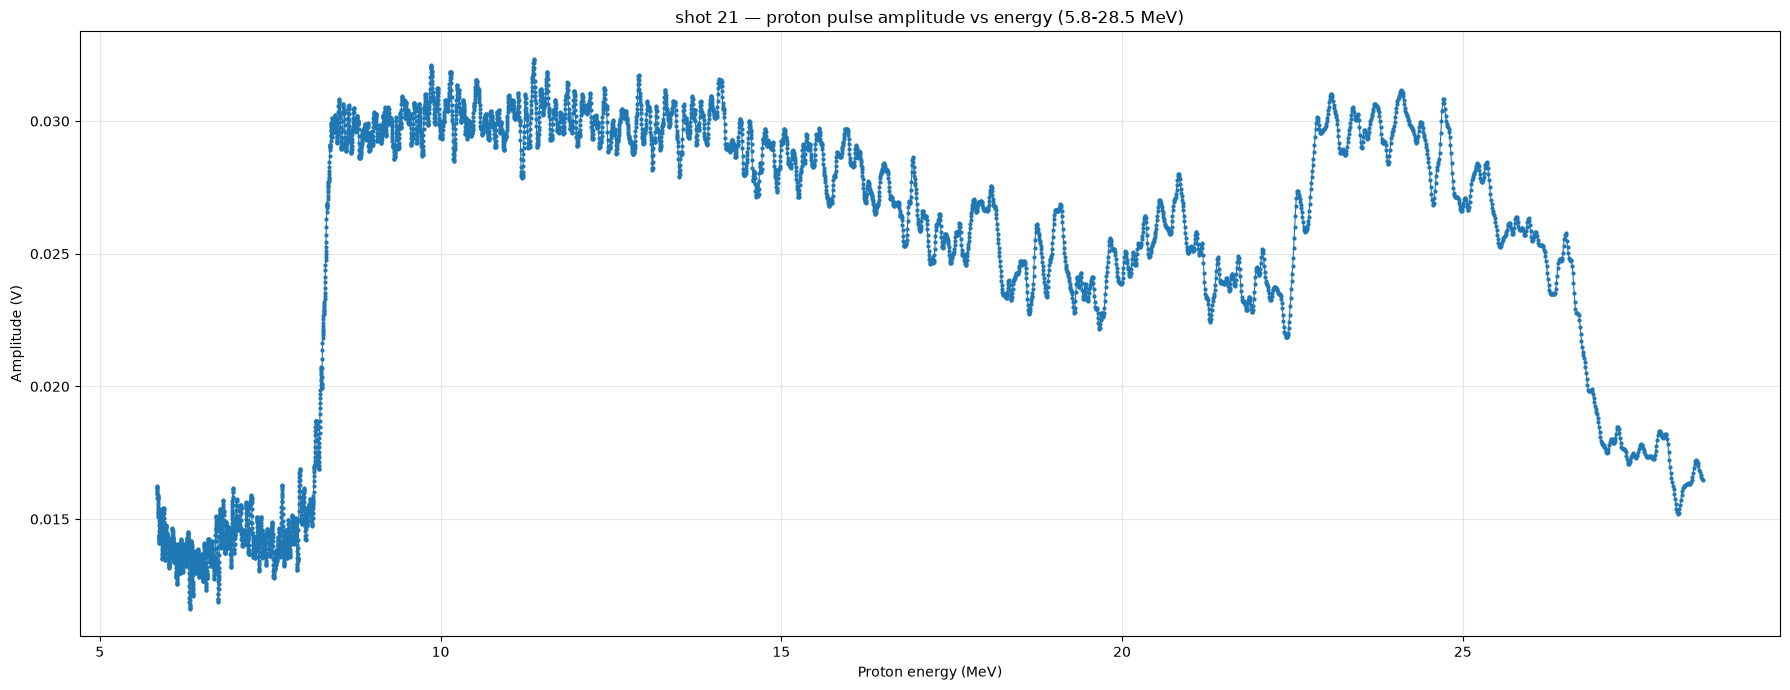

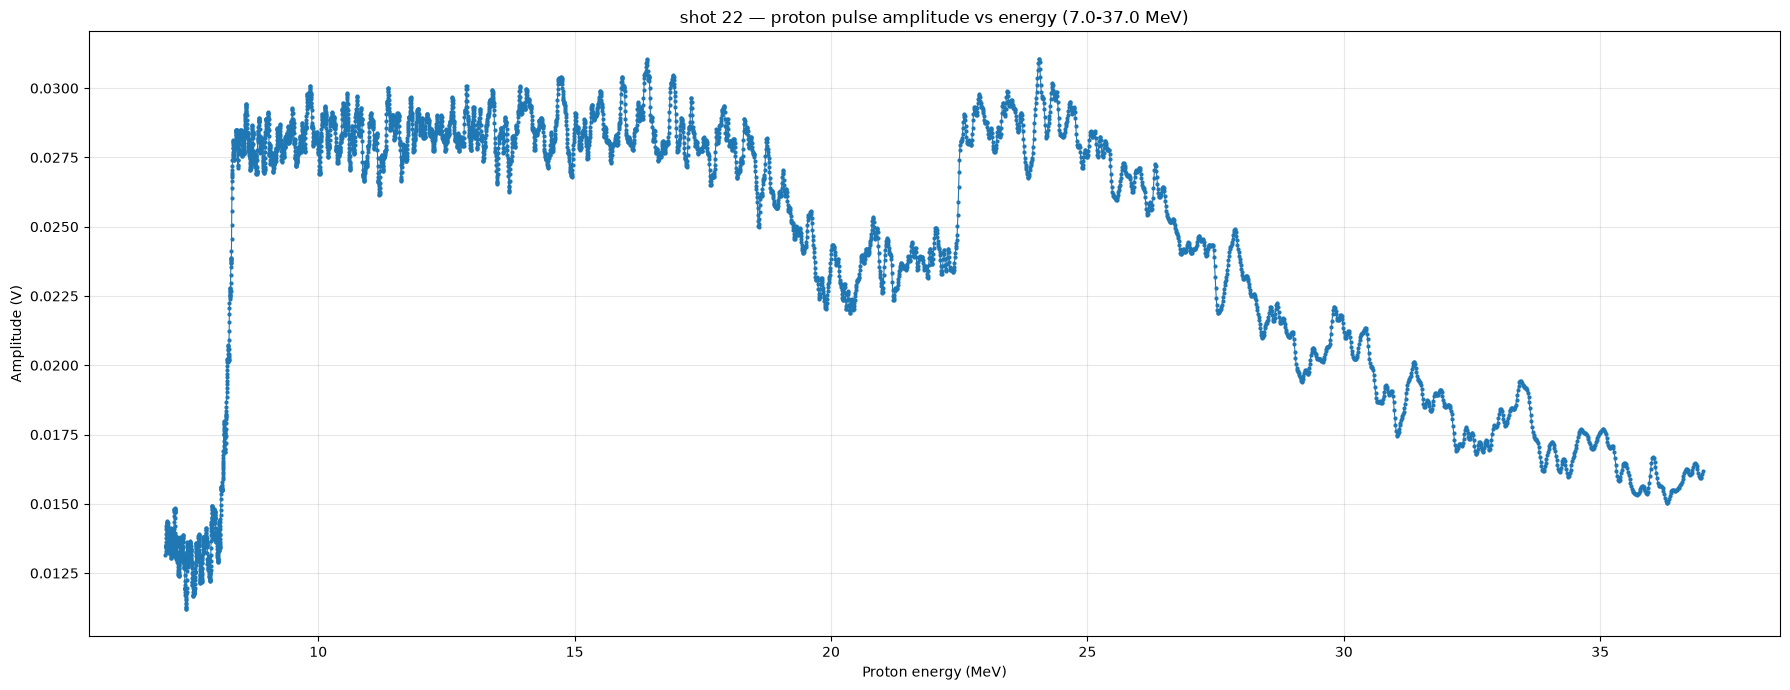

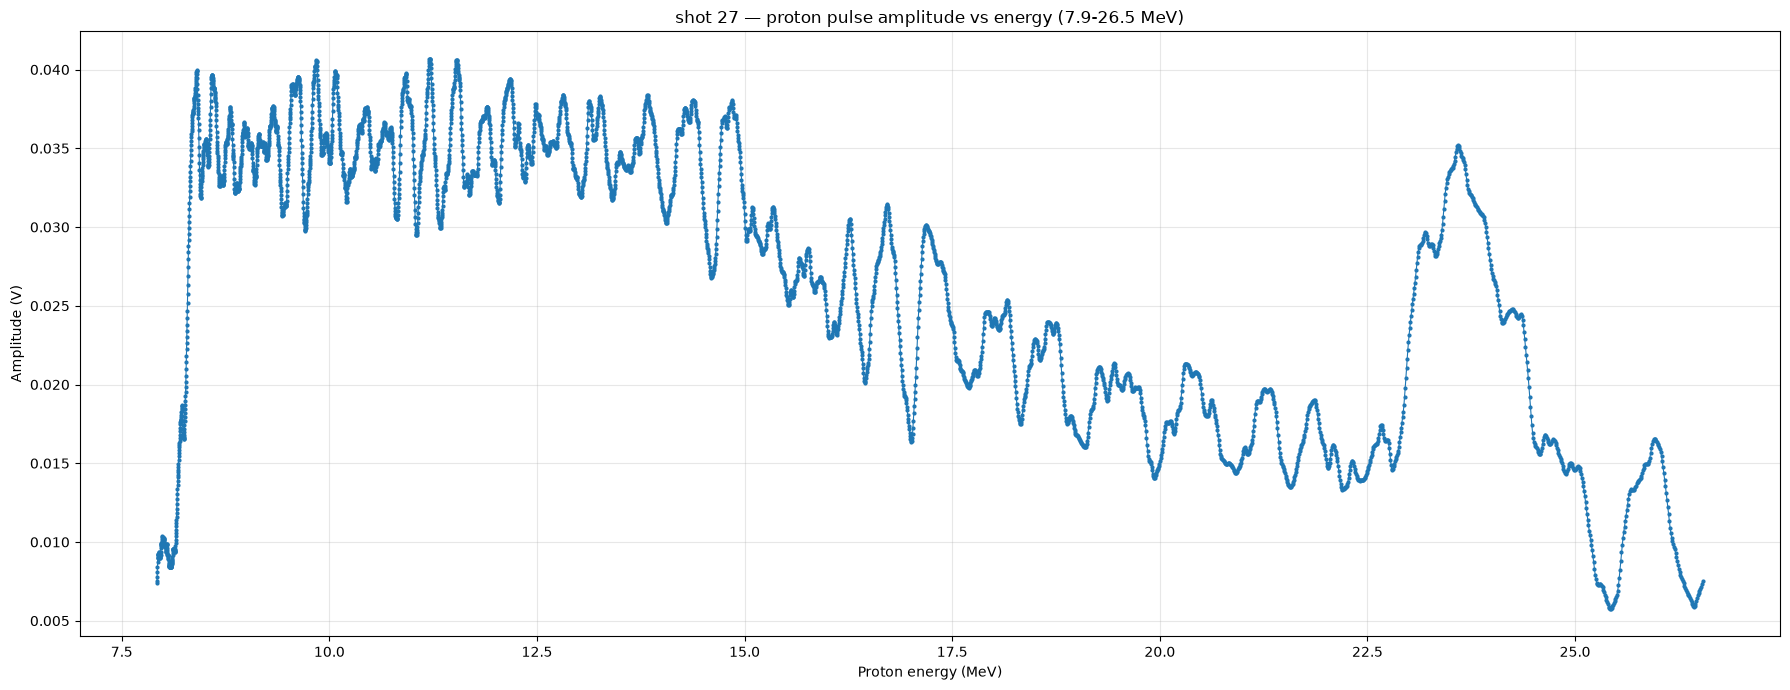

In [6]:
for shot in ENERGY_SHOTS:
    energy_spectrum_for_shot(shot)
